In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%matplotlib inline

In [4]:
# import dsharp_opac as opacity

In [5]:
kataoka_2014_colors = ['red', 'green', 'blue', 'magenta', 'chocolate']
kataoka_2014_ls = ['-', '--', (0, (3, 3)), ':', '-.']  # 3rd one is loosely dashed

## Test lambda values and a values

In [6]:
# Set up wavelength array
logwave_vals = np.linspace(0.1,5, 7500)

lambda_dist_micron = 10**logwave_vals

lambda_dist_cm = micron_to_cm(lambda_dist_micron)

In [7]:
# # a_max values for this plot
# a_max_micron_dist = [1, 100]
# a_max_cm_dist = micron_to_cm(a_max_micron_dist)

# Figure 2b: changing a, constant f

In [8]:
f_2b = 0.9999

In [9]:
a_2bd_micron = [0.1, 1, 10, 100, 1000]

a_2bd_cm = micron_to_cm(a_2bd_micron)

a_2bd_labels = ['0.1 $\mu$m', '1 $\mu$m', '10 $\mu$m', '100 $\mu$m', '1 mm']

In [10]:
oc, rho_g_cm3 = do.get_dsharp_mix(porosity = 1 - f_2b)

res_2b = do.get_opacities(a_2bd_cm, lambda_dist_cm, rho_g_cm3, oc)

k_abs_2b = res_2b['k_abs']

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
Mie ... Done!


In [11]:
k_abs_2b = res_2b['k_abs']
# k_sca_fig1 = res_fig1['k_sca']
# S1_fig1    = res_fig1['S1']
# S2_fig1    = res_fig1['S2']
# theta_fig1 = res_fig1['theta']

(0.0001, 100000.0)

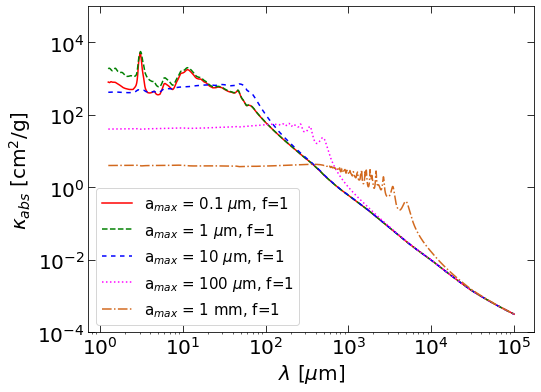

In [12]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(len(a_2bd_micron)):
    ax.plot(lambda_dist_micron,
            k_abs_2b[i],
            color = kataoka_2014_colors[i],
            ls = kataoka_2014_ls[i],
            label = rf'a$_{{max}}$ = {a_2bd_labels[i]}, f=1')


# Add axis labels
ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('$\kappa_{abs}$ [cm$^2$/g]', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.legend(loc = 'lower left',
          fontsize = legend_text_fs)
 
# Make axes log if needed
ax.set_xscale('log')
ax.set_yscale('log')

# Set axis limits
# ax.setxlim(0.11e4)
ax.set_ylim(10e-5, 10e4)

## Fig 2c: Constant a, changing f

In [13]:
a_2c_micron = np.array([1000])

a_2c_cm = micron_to_cm(a_2c_micron)

In [14]:
f_2cd = [0.9999, 10**-1, 10**-2, 10**-3, 10**-4]

f_2cd_labels = ['10^0', '10^{-1}', '10^{-2}', '10^{-3}', '10^{-4}']

In [15]:
k_abs_2c = []

for i in range(len(f_2cd)):
    
    print(rf'Now running f = {f_2cd[i]}')
    
    oc, rho_g_cm3 = do.get_dsharp_mix(porosity = 1 - f_2cd[i])
    
    res = do.get_opacities(a_2c_cm, lambda_dist_cm, rho_g_cm3, oc)

    k_abs = res['k_abs']

    k_abs_2c.append(k_abs)

Now running f = 0.9999
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
Mie ... Done!
Now running f = 0.1
Please cite Warren & Brandt (2008) when u

(1e-05, 100000.0)

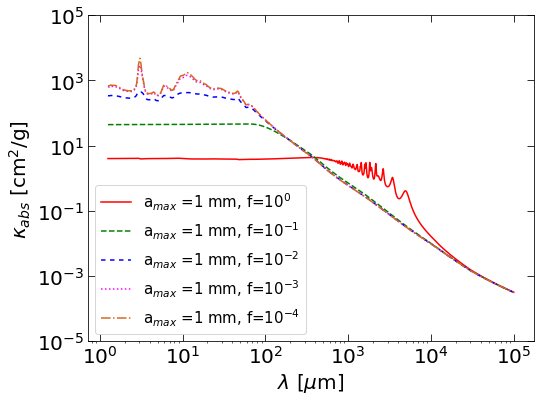

In [16]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(len(f_2cd )):
    ax.plot(lambda_dist_micron,
            k_abs_2c[i][0],
            color = kataoka_2014_colors[i],
            ls = kataoka_2014_ls[i],
            label = rf'a$_{{max}}$ =1 mm, f=${f_2cd_labels[i]}$')

# Add axis labels
ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('$\kappa_{abs}$ [cm$^2$/g]', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.legend(loc = 'lower left',
          fontsize = legend_text_fs)

# Make axes log if needed
ax.set_xscale('log')
ax.set_yscale('log')

# Set axis limits
# ax.setxlim(0.11e4)
ax.set_ylim(10e-6, 10e4)

## Fig 2d: changing a and f

In [17]:
k_abs_2d = []

for i in range(len(f_2cd)):
    
    print(rf'Now running a = {a_2bd_micron[i]} micron and f = {f_2cd[i]}')
    
    oc, rho_g_cm3 = do.get_dsharp_mix(porosity = 1 - f_2cd[i])
    
    res = do.get_opacities(a_2bd_cm, lambda_dist_cm, rho_g_cm3, oc)

    k_abs = res['k_abs']

    k_abs_2d.append(k_abs)

Now running a = 0.1 micron and f = 0.9999
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum
Mie ... Done!
Now running a = 1 micron and f = 0.1
Pleas

In [18]:
np.shape(k_abs_2d)

(5, 5, 7500)

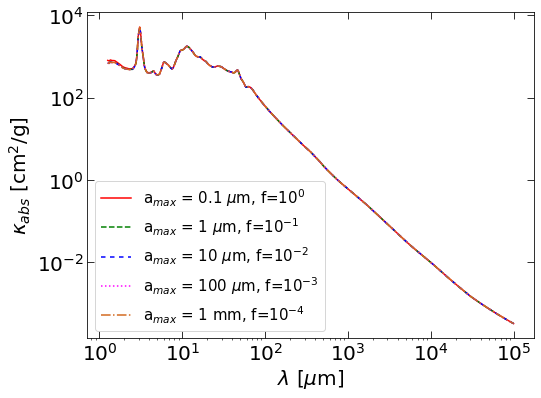

In [19]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(len(a_2bd_micron)):
    ax.plot(lambda_dist_micron,
            k_abs_2d[i][0],
            color = kataoka_2014_colors[i],
            ls = kataoka_2014_ls[i],
            label = rf'a$_{{max}}$ = {a_2bd_labels[i]}, f=${f_2cd_labels[i]}$')


# Add axis labels
ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('$\kappa_{abs}$ [cm$^2$/g]', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.legend(loc = 'lower left',
          fontsize = legend_text_fs)

# Make axes log if needed
ax.set_xscale('log')
ax.set_yscale('log')


# Set axis limits
# ax.setxlim(0.11e4)
# ax.set_ylim(10e-4, 10e4)

# All Plots together as a grid

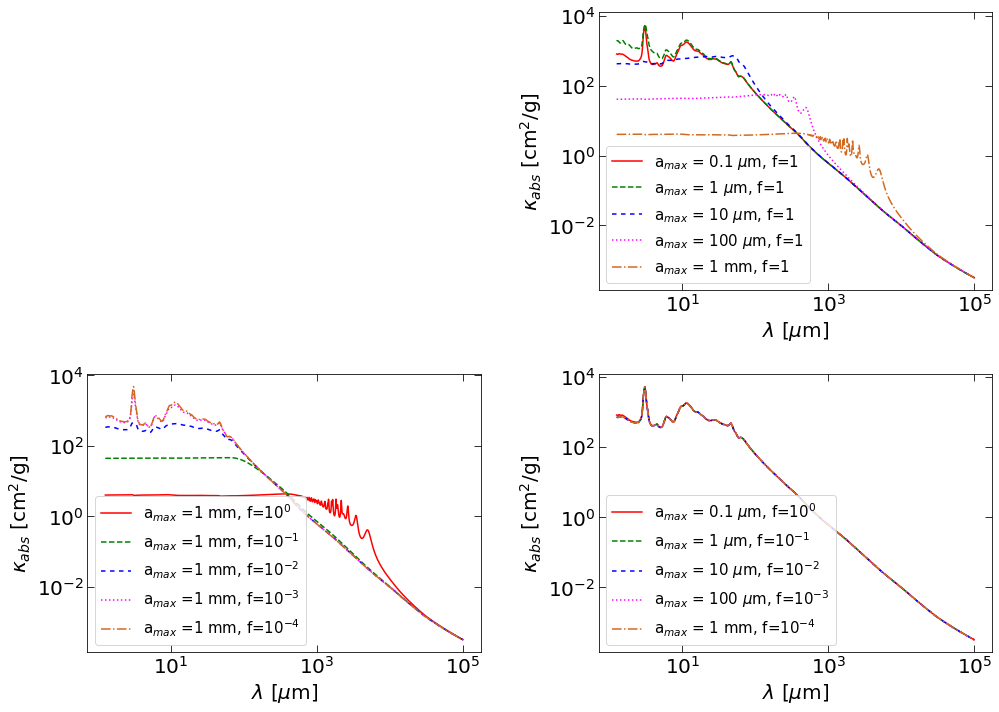

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Remove top-left axis (make it blank whitespace)
axs[0, 0].axis('off')

# === TOP RIGHT: Multiple grain sizes, f=1 ===
ax = axs[0, 1]
for i in range(len(a_2bd_micron)):
    ax.plot(lambda_dist_micron,
            k_abs_2b[i],
            color = kataoka_2014_colors[i],
            ls = kataoka_2014_ls[i],
            label = rf'a$_{{max}}$ = {a_2bd_labels[i]}, f=1')


# === BOTTOM LEFT: Varying porosity for 1 grain size ===
ax = axs[1, 0]
for i in range(len(f_2cd )):
    ax.plot(lambda_dist_micron,
            k_abs_2c[i][0],
            color = kataoka_2014_colors[i],
            ls = kataoka_2014_ls[i],
            label = rf'a$_{{max}}$ =1 mm, f=${f_2cd_labels[i]}$')


# === BOTTOM RIGHT: Varying porosity + grain sizes ===
ax = axs[1, 1]
for i in range(len(a_2bd_micron)):
    ax.plot(lambda_dist_micron,
            k_abs_2d[i][0],
            color = kataoka_2014_colors[i],
            ls = kataoka_2014_ls[i],
            label = rf'a$_{{max}}$ = {a_2bd_labels[i]}, f=${f_2cd_labels[i]}$')




for i in range(2):
    for j in range(2):
        
        
        if i == 0 and j == 0:
            continue  # skip top-left
            
        ax = axs[i, j]

        ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
        ax.set_ylabel('$\kappa_{abs}$ [cm$^2$/g]', fontsize=axis_label_fs)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.minorticks_on()
        ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
        ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        ax.legend(loc='lower left', fontsize=legend_text_fs)
    
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()
